# Task 2: Imitation Learning

## Setup Code / Packages
If you are running the code locally follow the instructions [here](../docs/setup.md).

If you are using Google Colab make sure to run the two cells below to install all dependencies and enable headless rendering. You will also need to upload your xml file to the assets folder.

In [19]:
import os, torch
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("torch =", torch.__version__)
print("torch.version.cuda =", torch.version.cuda)
print("is_available =", torch.cuda.is_available())
print("device_count =", torch.cuda.device_count())
if torch.cuda.is_available():
    print("device 0 =", torch.cuda.get_device_name(0))

CUDA_VISIBLE_DEVICES = None
torch = 2.11.0+cu130
torch.version.cuda = 13.0
is_available = False
device_count = 0


/home/tritondroids/miniconda3/envs/mujoco_cpu/lib/python3.11/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [1]:
import os, sys

# Pick MuJoCo backend
if sys.platform == "darwin":
    os.environ["MUJOCO_GL"] = "glfw"            # macOS
elif sys.platform.startswith("linux"):
    os.environ["MUJOCO_GL"] = "egl"            # Colab CPU default
else:
    os.environ["MUJOCO_GL"] = "glfw"

# Start a virtual display only on Linux (e.g., Colab)
if sys.platform.startswith("linux"):
    try:
        from pyvirtualdisplay import Display
        Display(visible=0, size=(1280,720)).start()
    except Exception:
        pass  # not installed (fine on macOS)


In [2]:
# import os
# # os.environ["MUJOCO_GL"] = "glfw"

In [3]:
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "task2":
    ROOT = ROOT.parent

XML_PATH = str(ROOT / "assets/descriptions/DropCubeInBinEnv.xml")
assert Path(XML_PATH).exists(), XML_PATH

## Using Gymnasium
No problems are assigned here, but understanding the code APIs/interfaces and functionalities are important.

### Gymnasium Basics
The Gymnasium package is a standardized API for creating and interacting with simulation environments. 

<img src="../assets/media/gym_loop.png" alt="agent-environment loop" width="500"/>

Gymnasium defines the agent-environment loop — a simple interface where an agent takes actions and receives observations, rewards, and termination signals from an environment. This loop forms the foundation for reinforcement learning (RL) and allows us to easily manipulate the simulator.

**Why We Use Gymnasium**

Gymnasium acts as a common interface layer between learning algorithms and simulation environments. It provides:
- A uniform API (reset(), step(), observation, reward, done, info) 
- Integration with RL algorithm libraries (e.g., Stable-Baselines3, CleanRL).
- Rendering and debugging utilities for visualization and evaluation.


In this task, you will use Gymnasium as the primary API to interface with the simulator to :
- Collect trajectory data for imitation learning.
- Evaluate and deploy trained policies.

Read their documentation [here](https://gymnasium.farama.org/).


## Part 0: Creating a Standardized Environment with Gymnasium
In this part, you will implement the `TrajEnv` class to wrap a MuJoCo simulation in a Gymnasium interface.

Your task is to decide which observations are useful as states in a behavior cloning setting. You will also implement the `is_grasped` property to define when the robot has successfully grasped the object and the `terminated` property to specify when the cube is in the bin. The `reset_model` method should randomize initial arm and object positions to encourage generalization.

You should step through Gymnasium functions like `do_simulation` and `set_state` to see how to control the simulator.

In [4]:
from scipy.spatial.transform import Rotation as R
from gymnasium.envs.mujoco import MujocoEnv
from gymnasium.spaces import Box
import numpy as np
import mujoco
import os

XML_PATH = os.path.abspath("../assets/descriptions/DropCubeInBinEnv.xml")


def _safe_body_id(model: mujoco.MjModel, body_name: str):
    try:
        return mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, body_name)
    except Exception:
        return None
    
def _safe_site_id(model, site_name: str):
        try:
            return mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, site_name)
        except Exception:
            return None

class TrajEnv(MujocoEnv):
    metadata = {"render_modes": ["human", "rgb_array", "depth_array"]}

    def __init__(self, xml_file: str, frame_skip: int = 5, **kwargs):
        # Starter observation: [qpos, qvel]. Extend this once your pipeline is stable.
        tmp_model = mujoco.MjModel.from_xml_path(xml_file)
        obs_dim = tmp_model.nq + tmp_model.nv
        if obs_dim == 0:
            print("Warning: observation dimension is 0. Complete Task 1 scene setup first.")

        observation_space = Box(
            low=-np.inf,
            high=np.inf,
            shape=(obs_dim,),
            dtype=np.float32,
        )

        super().__init__(
            xml_file,
            frame_skip,
            observation_space=observation_space,
            **kwargs,
        )

        # Useful body IDs. Keep as None-safe so the template remains robust.
        self.panda_id = _safe_body_id(self.model, "link0")
        self.hand_id = _safe_body_id(self.model, "hand")
        self.cube_id = _safe_body_id(self.model, "cube")
        self.bin_id = _safe_body_id(self.model, "simpleWoodBin")
        self.tcp_site_id = _safe_site_id(self.model, "tcp")

    def _body_pos(self, body_id):
        if body_id is None:
            return None
        return self.data.xpos[body_id].copy()
    
    def _site_pos(self, site_id):
        if site_id is None:
            return None
        return self.data.site_xpos[site_id].copy()

    def _distance_site_to_body(self, site_id, body_id):
        ps = self._site_pos(site_id)
        pb = self._body_pos(body_id)
        if ps is None or pb is None:
            return np.inf
        return np.linalg.norm(ps - pb)
    
    @property
    def is_grasped(self):
        # TODO: Replace this stub with your grasp condition.
        # Example signals: finger contact pairs, TCP-cube distance, cube lift height.
        if self.tcp_site_id is None or self.cube_id is None:
            return False
        dist = self._distance_site_to_body(self.tcp_site_id, self.cube_id)
        cube_pos = self._body_pos(self.cube_id)
        if cube_pos is None:
            return False
        lifted = cube_pos[2] > 0.82
        return (dist < 0.06) and lifted

    @property
    def terminated(self):
        # TODO: Replace this stub with your success condition.\n",
         # Example: cube center inside bin XY bounds and above bin floor.\n",   
        # Mark success only once the cube is actually resting in the bin,
        # not while it is still being carried above the opening.
        if self.cube_id is None or self.bin_id is None:
            return False

        cube_pos = self._body_pos(self.cube_id)
        bin_pos = self._body_pos(self.bin_id)
        tcp_pos = self._site_pos(self.tcp_site_id)

        if cube_pos is None or bin_pos is None:
            return False

        inside_xy = np.all(np.abs(cube_pos[:2] - bin_pos[:2]) < np.array([0.045, 0.045]))

        # Keep the cube within a vertical band around the bin interior.
        # The previous check only had a lower bound, so success triggered
        # while the gripper was still holding the cube above the bin.
        z_offset = cube_pos[2] - bin_pos[2]
        inside_z = 0.01 < z_offset < 0.12

        # Also require the TCP to no longer be right on top of the cube.
        released = True
        if tcp_pos is not None:
            released = np.linalg.norm(tcp_pos - cube_pos) > 0.05

        return inside_xy and inside_z and released


    def _get_obs(self):
        # TODO: Extend with task-relevant features once baseline is running.
        # qpos = self.data.qpos if self.data.qpos is not None else np.zeros(self.model.nq)
        # qvel = self.data.qvel if self.data.qvel is not None else np.zeros(self.model.nv)
        # return np.concatenate([qpos.ravel(), qvel.ravel()]).astype(np.float32)
        qpos = self.data.qpos
        qvel = self.data.qvel
        obs = np.concatenate([qpos.ravel(), qvel.ravel()])
        return obs.astype(np.float32)
    
    def _compute_reward(self):
        if self.cube_id is None or self.tcp_site_id is None:
            return 0.0
        dist = self._distance_site_to_body(self.tcp_site_id, self.cube_id)
        reach_reward = -dist
        grasp_bonus = 1.0 if self.is_grasped else 0.0
        success_bonus = 10.0 if self.terminated else 0.0
        return reach_reward + grasp_bonus + success_bonus

    def step(self, action: np.ndarray) -> tuple[np.ndarray, float, bool, bool, dict]:
        self.do_simulation(action, self.frame_skip)
        obs = self._get_obs()
        reward = self._compute_reward()  # TODO: optional shaping reward for diagnostics.
        terminated = self.terminated
        truncated = False
        info = {
            "is_grasped": self.is_grasped,
        }
        if self.render_mode == "human":
            self.render()
        # truncation=False as the TimeLimit wrapper handles episode truncation.
        return obs, reward, terminated, truncated, info

    def reset_model(self):
        try:
            default_qpos = np.array(self.model.keyframe("home").qpos, dtype=np.float32)
        except Exception:
            default_qpos = np.zeros(self.model.nq, dtype=np.float32)

        qpos = default_qpos.copy()
        qvel = np.zeros(self.model.nv, dtype=np.float32)

        # TODO: Randomize initial joint/object states with small ranges first.
        # qpos += np.random.normal(0, 0.01, size=qpos.shape)
        self.set_state(qpos, qvel)
        return self._get_obs()


To understand what is happening in the environment, you can call `env.render()` to visualize it.  
Since we set `render_mode="rgb_array"`, `env.render()` will return an RGB array that can be displayed.  


> **Note:** If the default view of the environment is not ideal, you may need to adjust the camera.  
> You can do this by defining a camera in your Mujoco XML file and then passing its name as a kwarg to the `TrajEnv` constructor via the `camera_name` argument.


If you are on colab you can render the environment like so. If you are running MuJoCo locally you can use `render_mode="human"` to display viewing window.


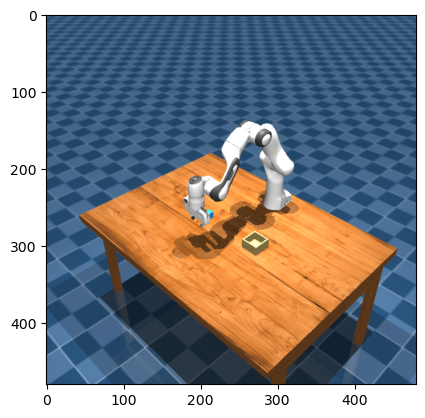

In [5]:
from gymnasium.wrappers import TimeLimit
import matplotlib.pyplot as plt

env = TrajEnv(XML_PATH, 20, render_mode='rgb_array', camera_name="fixed")
env = TimeLimit(env, 100)
env.reset()
image = env.render() 
image = image
plt.imshow(image)

With these core functionalities we can build the basic interaction loop that consists of a reset followed by steps until terminated or truncated is True. We can also record a video as well.

In [6]:
obs, _ = env.reset()
done = False
images = [env.render()]
# keep taking steps until either we terminated or truncate
while not done:
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
    images.append(env.render())
    done = terminated or truncated

In [7]:
from IPython.display import Video
import imageio

frames = images 
frames = [frame.astype(np.uint8) for frame in frames]   

# Write video to file
video_path = "output_video.mp4"
with imageio.get_writer(video_path, fps=20) as writer:
    for frame in frames:
        writer.append_data(frame)

# Display video in notebook
Video(video_path, embed=True)

We will now try and control the robot to grasp the cube, pick it up, and drop it in the wooden bin. 

The following code sets up a motion planning library for you and saves some useful variables. 
- `planner`: The planner objects uses screw motion planning.
- `panda_hand_tcp`: The panda hand tool center point "link", which gives the current pose of the link we are controlling via the motion planning library. This is the point in the middle between the two panda arm grippers.
- `cube`: The cube object, which you can use to acccess its pose.
- `bin`: The bin object.

The motion planner setup will generate a sequence joint position actions for all the joints excluding the gripper. The gripper actions you can manually pick (can range from 0 to 255). 

In [8]:
import mplib
from mplib import Pose
import os

env = TrajEnv(
    xml_file=XML_PATH, 
    frame_skip=20,
    render_mode="rgb_array"
    
)
env.reset(seed=42)

link_names = [
    'panda_link0','panda_link1','panda_link2','panda_link3','panda_link4',
    'panda_link5','panda_link6','panda_link7','panda_link8','panda_hand',
    'panda_hand_tcp','panda_leftfinger','panda_rightfinger',
    'panda_leftfinger_pad','panda_rightfinger_pad'
]
joint_names = [
    'panda_joint1','panda_joint2','panda_joint3','panda_joint4',
    'panda_joint5','panda_joint6','panda_joint7','panda_finger_joint1','panda_finger_joint2'
]

planner = mplib.Planner(
    urdf=os.path.abspath("../assets/descriptions/panda/urdf/panda.urdf"),
    srdf=os.path.abspath("../assets/descriptions/panda/urdf/panda.srdf"),
    user_link_names=link_names,
    user_joint_names=joint_names,
    move_group="panda_hand_tcp",
    joint_vel_limits=np.ones(7) * 0.8,
    joint_acc_limits=np.ones(7) * 0.8,
)

base_pos = env.data.xpos[env.panda_id].copy()
base_quat = env.data.xquat[env.panda_id].copy()

planner.set_base_pose(Pose(base_pos, base_quat))

# this sets the planner object up such that you can plan with poses in the world frame, which is the default frame of all pose data
# in our simulator
# planner.set_base_pose(np.concatenate([env.data.xpos[env.panda_id], env.data.xquat[env.panda_id]]))

**Notes for this task**

The goal is to use the motion planner to pick up the cube and drop it into the bin.

- You will need to access object positions and orientations from the simulator (env.data.xpos, env.data.xquat, etc.).
- The motion planner requires a target pose (7,) for the robot hand (position + quaternion) and the current joint configuration (qpos). Both are expressed in the world frame.
- Plan a trajectory to a consistent grasp pose above the cube, execute it while keeping the gripper open, then move down and close the gripper to pick up the cube.    
- Finally, open the gripper to release the cube into the bin.

The planner may fail if the pose is unreachable, collides with the environment, or the solver does not converge. This is expected—adjust poses or retry if needed.

In [13]:
from gymnasium.wrappers import RecordVideo

EPISODES = 3
GRIPPER_OPEN = 255.0
GRIPPER_CLOSE = 0.0

env = TrajEnv(
    xml_file=XML_PATH,
    frame_skip=20,
    render_mode="rgb_array"
)
env = RecordVideo(
    env,
    "videos",                         # folder to save videos
    episode_trigger=lambda e: True,    # record every episode
    name_prefix="planner"
)

def get_planner_qpos(env):
    base = env.unwrapped
    return base.data.qpos[:9].copy()

def make_action(planner_qpos, gripper_cmd):
    arm_qpos = np.asarray(planner_qpos, dtype=np.float32)[:7]
    return np.concatenate([
        arm_qpos,
        np.array([gripper_cmd], dtype=np.float32),
    ])

def log_step(env, action, episode_data=None):
    base = env.unwrapped

    # BC dataset 比較建議記「執行前 observation」對應這個 action
    obs = base._get_obs().copy()

    if episode_data is not None:
        episode_data.append((obs, action.copy()))

    obs2, reward, terminated, truncated, info = env.step(action)
    return obs2, reward, terminated, truncated, info

def execute_planned_path(env, result, gripper_cmd, episode_data=None):
    if result["status"] != "Success":
        return False

    for arm_qpos in result["position"]:
        action = make_action(arm_qpos, gripper_cmd)
        _, _, terminated, truncated, _ = log_step(env, action, episode_data)

        if terminated or truncated:
            break

    return True

def make_pose(pos, quat):
    return Pose(
        np.asarray(pos, dtype=np.float64).copy(),
        np.asarray(quat, dtype=np.float64).copy(),
    )

def offset_pose(pos, quat, offset):
    return make_pose(
        np.asarray(pos) + np.asarray(offset, dtype=np.float64),
        quat,
    )

def move_to_pose(env, target_pose, gripper_cmd, episode_data=None, time_step=0.02):
    planner_qpos = get_planner_qpos(env)

    result = planner.plan_screw(target_pose, planner_qpos, time_step=time_step)

    if result["status"] != "Success":
        result = planner.plan_pose(target_pose, planner_qpos, time_step=time_step)
        print("plan_pose :", result["status"])

    if result["status"] != "Success":
        print("Planning failed:", result["status"])
        return False

    return execute_planned_path(env, result, gripper_cmd, episode_data)

def hold_gripper(env, gripper_cmd, steps=30, episode_data=None):
    base = env.unwrapped
    arm_hold_qpos = base.data.qpos[:7].copy()

    for _ in range(steps):
        action = np.concatenate([
            arm_hold_qpos,
            np.array([gripper_cmd], dtype=np.float32),
        ])
        _, _, terminated, truncated, _ = log_step(env, action, episode_data)

        if terminated or truncated:
            break
        
def get_cube_pos(env):
    base = env.unwrapped
    return base.data.xpos[base.cube_id].copy()

def get_tcp_pos(env):
    base = env.unwrapped
    if base.tcp_site_id is None:
        return None
    return base.data.site_xpos[base.tcp_site_id].copy()
        
def settle_after_grasp(env, steps=8, episode_data=None):
    arm_hold_qpos = env.unwrapped.data.qpos[:7].copy()

    # 保持目前手臂位置，gripper 也保持 close
    for _ in range(steps):
        action = np.concatenate([
            arm_hold_qpos,
            np.array([GRIPPER_CLOSE], dtype=np.float32),
        ])
        _, _, terminated, truncated, _ = log_step(env, action, episode_data)
        if terminated or truncated:
            break
        
def log_positions(base, label=""):
    cube = base.data.xpos[base.cube_id].copy()
    tcp  = base.data.site_xpos[base.tcp_site_id].copy()
    print(f"[{label}] cube={np.round(cube, 4)}  tcp={np.round(tcp, 4)}")

/home/tritondroids/miniconda3/envs/mujoco_cpu/lib/python3.11/site-packages/gymnasium/wrappers/record_video.py:94: UserWarning: WARN: Overwriting existing videos at /data/tritondroids/yanglin/simulation/task2/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [14]:
base = env.unwrapped
cube_pos = base.data.xpos[base.cube_id].copy()
bin_pos = base.data.xpos[base.bin_id].copy()
grasp_quat = base.data.xquat[base.hand_id].copy()

def pick_cube_solution(env, episode_data=None):
    """Planner policy stub for data collection.

    TODO steps:
    1) Compute a target hand pose above the cube in world frame (shape (7,)).
    2) Read current robot joint positions in planner joint order.
    3) Plan with planner.plan_screw(...), execute trajectory, and log (obs, action).
    4) Add phases: approach -> descend -> close gripper -> lift -> move to bin -> open gripper.
    """
    base = env.unwrapped

    # 每次 reset 後都重新同步 planner 的 base pose，比較穩
    planner.set_base_pose(
        make_pose(
            base.data.xpos[base.panda_id].copy(),
            base.data.xquat[base.panda_id].copy(),
        )
    )

    cube_pos = base.data.xpos[base.cube_id].copy()
    bin_pos = base.data.xpos[base.bin_id].copy()

    # baseline: 先固定用目前 hand 的朝向
    grasp_quat = base.data.xquat[base.hand_id].copy()

    APPROACH_Z = 0.15
    GRASP_Z = 0.015
    LIFT_Z = 0.18
    BIN_ABOVE_Z = 0.18
    DROP_Z = 0.10
    GRASP_XY_OFFSET = np.array([0.0, -0.03, 0.0], dtype=np.float32)

    above_cube_pose = offset_pose(cube_pos + GRASP_XY_OFFSET, grasp_quat, [0.0, 0.0, APPROACH_Z])
    grasp_pose = offset_pose(cube_pos + GRASP_XY_OFFSET, grasp_quat, [0.0, 0.0, GRASP_Z])
    lift_pose = offset_pose(cube_pos + GRASP_XY_OFFSET, grasp_quat, [0.0, 0.0, LIFT_Z])
    above_bin_pose = offset_pose(bin_pos, grasp_quat, [0.0, 0.0, BIN_ABOVE_Z])
    drop_pose = offset_pose(bin_pos, grasp_quat, [0.0, 0.0, DROP_Z])

    # 1) approach above cube
    if not move_to_pose(env, above_cube_pose, GRIPPER_OPEN, episode_data):
        return False
    # log_positions(base, "approach")

    # 2) descend
    if not move_to_pose(env, grasp_pose, GRIPPER_OPEN, episode_data):
        return False
    # log_positions(base, "descend")

    # 3) close gripper
    hold_gripper(env, GRIPPER_CLOSE, steps=25, episode_data=episode_data)
    # log_positions(base, "gripper_close")

    settle_after_grasp(env, steps=20, episode_data=episode_data)
    # log_positions(base, "settle")

    # 4) lift
    if not move_to_pose(env, lift_pose, GRIPPER_CLOSE, episode_data):
        return False
    # log_positions(base, "lift")

    settle_after_grasp(env, steps=8, episode_data=episode_data)

    # 5) move above bin
    if not move_to_pose(env, above_bin_pose, GRIPPER_CLOSE, episode_data):
        return False
    # log_positions(base, "above_bin")

    # 6) descend to bin
    if not move_to_pose(env, drop_pose, GRIPPER_CLOSE, episode_data):
        return False
    # log_positions(base, "drop")

    # 7) open gripper
    hold_gripper(env, GRIPPER_OPEN, steps=12, episode_data=episode_data)
    # log_positions(base, "gripper_open")

    # 8) retreat
    if not move_to_pose(env, above_bin_pose, GRIPPER_OPEN, episode_data):
        return False
    # log_positions(base, "retreat")

    return bool(base.terminated)

RUN_PLANNER_DEMO = True  # Set to True after implementing pick_cube_solution

if RUN_PLANNER_DEMO:
    successes = 0
    for i in range(EPISODES):
        env.reset(seed=i)

        base = env.unwrapped

        planner.set_base_pose(
            make_pose(
                base.data.xpos[base.panda_id].copy(),
                base.data.xquat[base.panda_id].copy(),
            )
        )

        success = pick_cube_solution(env)
        successes += bool(success)

        print(f"Episode {i}: {success}")

    print(f"Success rate: {successes / EPISODES}")

env.close()


MoviePy - Building video /data/tritondroids/yanglin/simulation/task2/videos/planner-episode-0.mp4.
MoviePy - Writing video /data/tritondroids/yanglin/simulation/task2/videos/planner-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /data/tritondroids/yanglin/simulation/task2/videos/planner-episode-0.mp4
Episode 0: True
MoviePy - Building video /data/tritondroids/yanglin/simulation/task2/videos/planner-episode-1.mp4.
MoviePy - Writing video /data/tritondroids/yanglin/simulation/task2/videos/planner-episode-1.mp4



MoviePy - Done !
MoviePy - video ready /data/tritondroids/yanglin/simulation/task2/videos/planner-episode-1.mp4
Episode 1: True
MoviePy - Building video /data/tritondroids/yanglin/simulation/task2/videos/planner-episode-2.mp4.
MoviePy - Writing video /data/tritondroids/yanglin/simulation/task2/videos/planner-episode-2.mp4



MoviePy - Done !
MoviePy - video ready /data/tritondroids/yanglin/simulation/task2/videos/planner-episode-2.mp4
Episode 2: True
Success rate: 1.0


In [15]:
from IPython.display import Video
Video("videos/planner-episode-0.mp4", embed=True, width=800, height=800) # Watch replay

## Part 1: Collect your Imitation Learning Dataset


Now that you’ve used the motion planner to complete a single pick-and-place sequence, the next step is to repeat this process many times to collect a dataset for imitation learning.

In imitation learning, the dataset is made of trajectories—sequences of state-action pairs showing how an expert (in this case, the motion planner) solves the task. Each trajectory will later be used to train a policy that imitates this behavior.

>**Tip**: Standardizing the orientation and approach of the gripper will help the robot pick up the cube in the same way each time, resulting in a more reliable model.


In [18]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False
No GPU


/home/tritondroids/miniconda3/envs/mujoco_cpu/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [ ]:
import pickle

env = TrajEnv(
    xml_file=XML_PATH,
    frame_skip=20,
)

trajectories = []

EPISODES = 10_000
success_count = 0

for i in range(EPISODES):
    env.reset()
    episode_data = []

    # This sets the planner object up such that you can plan with poses in the world frame.
    planner.set_base_pose(
        make_pose(
            env.data.xpos[env.panda_id].copy(),
            env.data.xquat[env.panda_id].copy(),
        )
    )

    try:
        result = pick_cube_solution(env, episode_data)
    except NotImplementedError as exc:
        raise RuntimeError("Implement pick_cube_solution before collecting dataset trajectories.") from exc

    if result:
        trajectories.append(episode_data)
        print(f"Episode {i} completed successfully.")
        success_count += 1

# ===== Save dataset =====
with open("pick_place_dataset.pkl", "wb") as f:
    pickle.dump(trajectories, f)

print(f"Success rate: {success_count / EPISODES}")
print(f"Total trajectories: {len(trajectories)}")
env.close()


Episode 0 completed successfully.
Episode 1 completed successfully.
Episode 2 completed successfully.
Episode 3 completed successfully.
Episode 4 completed successfully.
Episode 5 completed successfully.
Episode 6 completed successfully.
Episode 7 completed successfully.
Episode 8 completed successfully.
Episode 9 completed successfully.
Episode 10 completed successfully.
Episode 11 completed successfully.
Episode 12 completed successfully.
Episode 13 completed successfully.
Episode 14 completed successfully.
Episode 15 completed successfully.
Episode 16 completed successfully.
Episode 17 completed successfully.
Episode 18 completed successfully.
Episode 19 completed successfully.
Episode 20 completed successfully.
Episode 21 completed successfully.
Episode 22 completed successfully.
Episode 23 completed successfully.
Episode 24 completed successfully.
Episode 25 completed successfully.
Episode 26 completed successfully.
Episode 27 completed successfully.
Episode 28 completed successfu

## Part 2: Create Behavior Cloning Dataset

Using the trajectory data you have collected in the previous task, complete the `TrajectoryDataset` class to feed your model. 

>**NOTE**: The model learns to map states to actions, so the order of the data is not important. You can flatten all episodes and sample from any step freely.

In [ ]:
from torch.utils.data import Dataset
import pickle


class TrajectoryDataset(Dataset):
    def __init__(self, data):
        raise NotImplementedError("TODO: flatten trajectory list into (obs, action) training pairs")

    def __len__(self):
        raise NotImplementedError("TODO: return number of flattened samples")

    def __getitem__(self, idx):
        # This should return observation idx and action idx.
        raise NotImplementedError("TODO: return (obs[idx], action[idx])")


dataset_file = "pick_place_dataset.pkl"
with open(dataset_file, "rb") as f:
    data = pickle.load(f)
dataset = TrajectoryDataset(data)


## Part 3: Define the Policy Network

In this step, you will implement a behavior cloning policy network. The goal of this network is to learn to map observations (states) to actions by imitating the trajectories you collected earlier. 

**NOTE**: See [tips](tips.md) for guidance on designing your network architecture and BC overview.

In [ ]:
import torch.nn as nn


class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Define the network architecture.
        # Recommended: shared MLP trunk with separate mean/log_std heads.
        raise NotImplementedError("TODO: implement Actor.__init__")

    def forward(self, x):
        raise NotImplementedError("TODO: return mean, log_std")


## Part 4: Training Loop
You will train the neural network policy to imitate expert behavior.

We’ve provided an `eval_policy` function to test your actor in simulation. It runs several episodes and reports a success rate, so you can track how well your policy performs as training progresses.

In [ ]:
import gymnasium as gym
import torch.nn as nn
import numpy as np
import torch

def eval_policy(eval_env: gym.Env, actor: nn.Module, num_episodes: int = 5):
    success = 0
    for ep in range(num_episodes):
        obs, _ = eval_env.reset()
        terminated, truncated = False, False
        
        while not (terminated or truncated):
            with torch.no_grad():
                action, _ = actor(torch.from_numpy(obs).float())
            obs, _, terminated, truncated, _ = eval_env.step(action.cpu().numpy())

        if terminated:
            success += 1
        
        print(f"Episode {ep+1}: Success={terminated}")
    return success / num_episodes

In [ ]:
from torch.utils.data import DataLoader
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(0)
np.random.seed(0)

actor = Actor().to(device)
eval_env = TrajEnv(XML_PATH, 20)

batch_size = 1024
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

lr = 3e-5
epochs = 100

def nll_loss(actor: nn.Module, obs: torch.Tensor, expert_actions: torch.Tensor):
    mean, log_std = actor(obs)
    std = log_std.exp()
    dist = torch.distributions.Normal(mean, std)
    log_prob = dist.log_prob(expert_actions).sum(-1)   #sum over action dims
    loss = -log_prob.mean()
    return loss

# TODO: Write the training loop
# Train the actor policy to predict the actions in the dataset.
# Make sure to run the eval_policy function every once in a while to track training progress
# and save your best policy checkpoint to be loaded later for evaluation. 
# If you are confident in your model, sometimes a different seed can work. 
# Training time depends on number of samples and number of epochs, but should not take more than 10 minutes on google colab.


## Part 5: Evaluate in Simulator
Time to evaluate your model. You may notice that it doesn’t succeed very often and may behave unpredictably or erratically. 

Can you think about why this might happen?

In [ ]:
import torch
import numpy as np
from gymnasium.wrappers import RecordVideo


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(0)
np.random.seed(0)

eval_env = TrajEnv(XML_PATH, 20, render_mode='rgb_array')
eval_env = RecordVideo(
    eval_env,
    "videos",                       # folder to save videos
    episode_trigger=lambda e: True,  # record every episode
    name_prefix="bc-model"
    )
actor = Actor().to(device)

state_dict = torch.load('best_policy.pth')
actor.load_state_dict(state_dict)

#Evaluation
eval_policy(eval_env, actor, 5)
eval_env.close()

In [ ]:
from IPython.display import Video
Video("videos/bc-model-episode-0.mp4", embed=True, width=320) # Watch our replay